# Лабораторная работа №1: Детектирование объектов

**Цель**
Познакомиться с современными методами детектирования объектов (YOLO, Faster R-CNN), научиться применять предобученные модели и дообучать их на собственных данных.

**Теория**
- Object Detection: отличие от классификации и сегментации.
- Архитектуры: YOLO, SSD, Faster R-CNN.
- Метрики: IoU, mAP.

**Задания**
1. Выберите одну из моделей (YOLOv8 или Faster R-CNN).
2. Загрузите предобученную модель и примените её к набору изображений (COCO subset, Pascal VOC или небольшой кастомный датасет).
3. Проведите fine-tuning на кастомном датасете (5–10 классов).
4. Оцените качество модели: постройте метрику mAP при разных IoU порогах.
5. Визуализируйте предсказания модели на тестовых изображениях.

**Вопросы**
1. Чем one-stage детекторы отличаются от two-stage?
2. Какие ошибки чаще всего допускает модель при детекции?

**Требуемое содержание файла проекта**
- Краткий обзор выбранной модели.
- Иллюстрации работы до и после дообучения.
- Графики/таблицы с результатами.
- Ответы на контрольные вопросы.

## 1. Выбор модели

В работе используется **Faster R-CNN ResNet-50 FPN v2** из `torchvision`, предобученная на COCO. Это двухэтапный детектор: сначала он находит области, где могут находиться объекты, затем определяет их классы и уточняет границы. Результат обработки изображения — ограничивающие рамки, метки классов и оценки уверенности.

### Как устроена модель

**ResNet-50 — извлечение признаков.** Свёрточная сеть преобразует изображение в карты признаков: от локальных деталей до более сложных признаков объектов. Остаточные связи помогают обучать глубокую сеть, передавая информацию и градиенты между слоями.

**FPN — работа с разными масштабами.** Пирамида признаков объединяет информацию с нескольких уровней ResNet-50. Благодаря этому детектор использует как детальные карты высокого разрешения, так и признаки с более широким контекстом. Для Aquarium это полезно: в одном кадре могут присутствовать крупная акула и небольшие рыбы на заднем плане.

**RPN — поиск областей-кандидатов.** Region Proposal Network рассматривает опорные рамки разных размеров и пропорций. Для каждой она оценивает наличие объекта и корректирует координаты. Отобранные предложения передаются на следующий этап.

**RoIAlign и голова детектора — распознавание объектов.** RoIAlign извлекает признаки фиксированного размера для каждой предложенной области. Затем голова модели определяет класс объекта, включая служебный класс фона, и дополнительно уточняет рамку. При получении предсказаний подавление немаксимумов (NMS) уменьшает число дублирующих рамок.

### Особенности выбранного подхода

- **Два этапа обработки:** поиск потенциальных объектов и их подробная классификация выполняются последовательно.
- **Многомасштабные признаки:** FPN помогает обрабатывать объекты разного размера, хотя маленькие и перекрывающиеся объекты остаются сложными.
- **Перенос обучения:** веса COCO служат начальной точкой для дообучения на Aquarium.
- **Вычислительная стоимость:** обработка предложенных областей требует памяти и времени; при обучении важно подобрать размер батча.

### Функции потерь

Общая функция потерь складывается из четырёх компонентов, которые возвращает используемая реализация `torchvision`.

| Компонент | Функция | Что обучается |
|---|---|---|
| `loss_objectness` | Binary Cross-Entropy with logits | Оценка наличия объекта в опорной рамке RPN |
| `loss_rpn_box_reg` | Smooth L1 | Уточнение рамок на этапе RPN |
| `loss_classifier` | Cross-Entropy | Выбор класса объекта или фона |
| `loss_box_reg` | Smooth L1 | Уточнение координат рамок на втором этапе |

Регрессия рамок обучается на положительных примерах. При просмотре истории полезно учитывать отдельные компоненты: уменьшение общей loss само по себе не гарантирует роста mAP.

### Почему Faster R-CNN подходит для этой работы

Модель позволяет изучить весь процесс детектирования: предложения областей, классификацию и локализацию. Предобученные веса дают возможность дообучить детектор на сравнительно небольшом Aquarium, а FPN полезна для сцен с объектами разных размеров. В работе выходной предиктор заменён на **8 классов: 7 категорий Aquarium и фон**. Исходная модель COCO и дообученная модель имеют разные наборы меток, поэтому это различие учитывается при сравнении предсказаний.

## 2. Загрузка предобученной модели и применение к изображениям

### 2.1 Загрузка модели

In [1]:
import torch
import torchvision
from torchvision.models.detection import (
    FasterRCNN_ResNet50_FPN_V2_Weights,
    fasterrcnn_resnet50_fpn_v2,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"Устройство: {DEVICE}")

IS_CUDA = DEVICE.type == "cuda"
if IS_CUDA:
    print(f"Имя устройства: {torch.cuda.get_device_name(0)}")

PyTorch: 2.13.0+cu130
Torchvision: 0.28.0+cu130
Устройство: cuda
Имя устройства: NVIDIA GeForce RTX 4060


In [2]:
# При первом запуске torchvision автоматически скачиваем веса COCO
weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn_v2(weights=weights)
model = model.to(DEVICE)
model.eval()

# Преобразования и названия 91 категории COCO, соответствующие весам
preprocess = weights.transforms()
class_names = weights.meta["categories"]

print(f"Модель: {model.__class__.__name__}")
print(f"Количество категорий COCO: {len(class_names)}")

Модель: FasterRCNN
Количество категорий COCO: 91


In [3]:
# Быстрая проверка инференса на тестовом изображении
test_image = torch.rand(3, 480, 640, device=DEVICE)
with torch.inference_mode():
    test_prediction = model([test_image])[0]

print("Поля результата:", test_prediction.keys())
print("Размер boxes:", tuple(test_prediction["boxes"].shape))
print("Модель готова к обработке изображений.")

Поля результата: dict_keys(['boxes', 'labels', 'scores'])
Размер boxes: (1, 4)
Модель готова к обработке изображений.


### 2.2. Подготовка датасета Aquarium.

Датасет содержит 638 изображений и 7 классов объектов. Разметка представлена в формате COCO JSON. Включает разделы `train`, `valid` и `test`.

In [4]:
import json
from collections import defaultdict
from pathlib import Path

from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms.functional import pil_to_tensor

DATA_ROOT = Path("datasets/aquarium")

class CocoJsonDetectionDataset(Dataset):
    def __init__(self, split_dir):
        self.split_dir = Path(split_dir)
        annotation_path = self.split_dir / "_annotations.coco.json"
        with annotation_path.open(encoding="utf-8") as file:
            coco = json.load(file)

        self.images = sorted(coco["images"], key=lambda item: item["id"])
        self.annotations = defaultdict(list)
        for annotation in coco["annotations"]:
            self.annotations[annotation["image_id"]].append(annotation)

        # 0 используется как фон; реальные классы датасета имеют ID 1–7
        self.categories = {
            category["id"]: category["name"]
            for category in coco["categories"]
            if category["id"] != 0
        }

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image_info = self.images[index]
        image = Image.open(self.split_dir / image_info["file_name"]).convert("RGB")
        image = pil_to_tensor(image).float() / 255.0

        boxes, labels, areas, iscrowd = [], [], [], []
        for annotation in self.annotations[image_info["id"]]:
            x, y, width, height = annotation["bbox"]
            if width <= 0 or height <= 0:
                continue
            boxes.append([x, y, x + width, y + height])
            labels.append(annotation["category_id"])
            areas.append(annotation.get("area", width * height))
            iscrowd.append(annotation.get("iscrowd", 0))

        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32).reshape(-1, 4),
            "labels": torch.as_tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor(image_info["id"], dtype=torch.int64),
            "area": torch.as_tensor(areas, dtype=torch.float32),
            "iscrowd": torch.as_tensor(iscrowd, dtype=torch.int64),
        }
        return image, target

def collate_fn(batch):
    return tuple(zip(*batch))

In [5]:
train_dataset = CocoJsonDetectionDataset(DATA_ROOT / "train")
valid_dataset = CocoJsonDetectionDataset(DATA_ROOT / "valid")
test_dataset = CocoJsonDetectionDataset(DATA_ROOT / "test")

train_loader = DataLoader(
    train_dataset, batch_size=2, shuffle=True,
    num_workers=0, collate_fn=collate_fn, pin_memory=True,
)
valid_loader = DataLoader(
    valid_dataset, batch_size=2, shuffle=False,
    num_workers=0, collate_fn=collate_fn, pin_memory=True,
)
test_loader = DataLoader(
    test_dataset, batch_size=2, shuffle=False,
    num_workers=0, collate_fn=collate_fn, pin_memory=True,
)

print("Классы:", train_dataset.categories)
print(f"Train: {len(train_dataset)}, valid: {len(valid_dataset)}, test: {len(test_dataset)}")
images, targets = next(iter(train_loader))
print("Размер первого изображения:", tuple(images[0].shape))
print("Число объектов на нём:", len(targets[0]["boxes"]))

Классы: {1: 'fish', 2: 'jellyfish', 3: 'penguin', 4: 'puffin', 5: 'shark', 6: 'starfish', 7: 'stingray'}
Train: 448, valid: 127, test: 63
Размер первого изображения: (3, 2048, 1536)
Число объектов на нём: 12


In [6]:
from torchvision.utils import draw_bounding_boxes

def draw_detections(image, boxes, labels, names, scores=None, threshold=0.0, color="red"):
    image_uint8 = (image.detach().cpu().clamp(0, 1) * 255).to(torch.uint8)
    boxes = boxes.detach().cpu()
    labels = labels.detach().cpu()
    if scores is None:
        keep = torch.ones(len(labels), dtype=torch.bool)
        captions = [names.get(int(label), str(int(label))) for label in labels]
    else:
        scores = scores.detach().cpu()
        keep = scores >= threshold
        captions = [
            f"{names.get(int(label), str(int(label)))} {float(score):.2f}"
            for label, score in zip(labels[keep], scores[keep])
        ]
    boxes = boxes[keep]
    if len(boxes) == 0:
        return image_uint8
    from PIL import Image, ImageDraw, ImageFont
    import hashlib
    import colorsys

    canvas = Image.fromarray(image_uint8.permute(1, 2, 0).numpy())
    painter = ImageDraw.Draw(canvas)
    # Масштабируем подписи относительно исходного изображения.
    font_size = max(18, round(min(canvas.size) / 32))
    font_path = Path("C:/Windows/Fonts/arial.ttf")
    font = ImageFont.truetype(str(font_path) if font_path.exists() else "DejaVuSans.ttf", font_size)
    line_width = max(3, round(min(canvas.size) / 300))
    aquarium_colors = {
        "fish": "#00d5ff", "jellyfish": "#ff70db", "penguin": "#ffca28",
        "puffin": "#ab8cff", "shark": "#ff7043", "starfish": "#7ee850",
        "stingray": "#40e0b0",
    }
    # Цвет зависит от имени: одинаковые классы всегда имеют одинаковый цвет.
    def class_color(name):
        if name in aquarium_colors:
            return aquarium_colors[name]
        hue = int(hashlib.sha256(name.encode()).hexdigest()[:8], 16) / 0xffffffff
        return tuple(round(v * 255) for v in colorsys.hsv_to_rgb(hue, .7, 1.0))

    for box, label, caption in zip(boxes, labels[keep], captions):
        name = names.get(int(label), str(int(label)))
        outline = class_color(name)
        x1, y1, x2, y2 = box.tolist()
        painter.rectangle((x1, y1, x2, y2), outline=outline, width=line_width)
        text_box = painter.textbbox((0, 0), caption, font=font)
        tw, th = text_box[2] - text_box[0], text_box[3] - text_box[1]
        padding = max(3, font_size // 8)
        tx = max(0, min(x1, canvas.width - tw - 2 * padding))
        ty = max(0, min(y1 - th - 2 * padding, canvas.height - th - 2 * padding))
        painter.rectangle((tx, ty, tx + tw + 2 * padding, ty + th + 2 * padding), fill=outline)
        painter.text((tx + padding - text_box[0], ty + padding - text_box[1]),
                     caption, font=font, fill="black")
    return torch.from_numpy(__import__("numpy").array(canvas).copy()).permute(2, 0, 1)



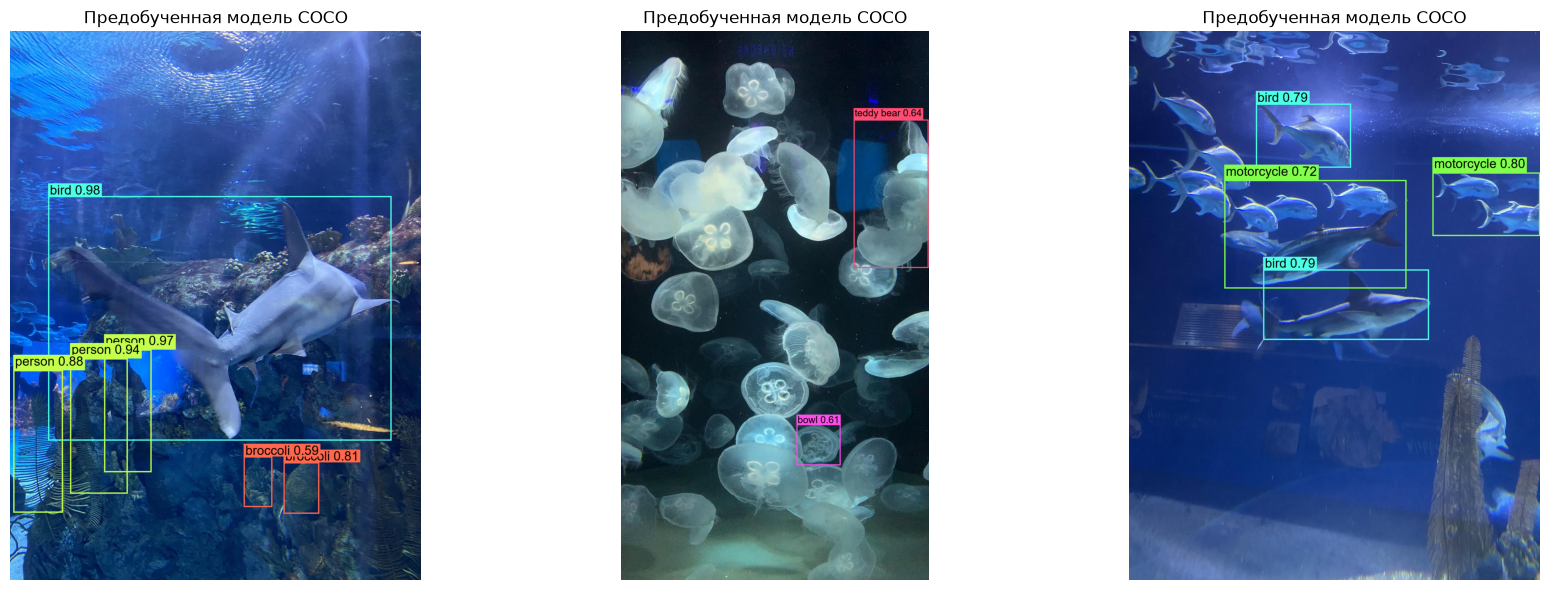

In [7]:
SCORE_THRESHOLD = 0.50
aquarium_names = {0: "background", **train_dataset.categories}

sample_indices = [0, len(test_dataset) // 2, len(test_dataset) - 1]
sample_items = [test_dataset[index] for index in sample_indices]
sample_images = [item[0] for item in sample_items]
sample_targets = [item[1] for item in sample_items]

# Baseline: исходная COCO-модель.
pretrained_model = fasterrcnn_resnet50_fpn_v2(weights=weights).to(DEVICE).eval()
with torch.inference_mode():
    baseline_predictions = pretrained_model([image.to(DEVICE) for image in sample_images])
del pretrained_model
if IS_CUDA:
    torch.cuda.empty_cache()


import matplotlib.pyplot as plt
figure, axes = plt.subplots(1, len(sample_images), figsize=(18, 6))
for axis, image, prediction in zip(axes, sample_images, baseline_predictions):
    rendered = draw_detections(image, prediction['boxes'], prediction['labels'],
        dict(enumerate(class_names)), prediction['scores'], SCORE_THRESHOLD, 'orange')
    axis.imshow(rendered.permute(1, 2, 0))
    axis.set_title('Предобученная модель COCO')
    axis.axis('off')
plt.tight_layout()
plt.show()

## 3. Fine-tuning на кастомном датасете

### 3.1. Подготовка модели
Исходная голова модели рассчитана на категории COCO. Заменим её классификатором для 8 выходов: 7 классов Aquarium и один служебный класс фона.

In [8]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

NUM_CLASSES = len(train_dataset.categories) + 1  # 7 классов + фон

def set_predictor(model):
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

set_predictor(model)
model = model.to(DEVICE)

print(f"Новая голова Faster R-CNN: {NUM_CLASSES} выходов")

Новая голова Faster R-CNN: 8 выходов


### 3.2. Обучение модели
Дообучим все параметры модели с помощью SGD. Для ускорения на CUDA используется mixed precision. После каждой эпохи вычисляется validation loss; checkpoint с наименьшим значением сохраняется в `artifacts/lab1/fasterrcnn_aquarium_best.pth`, а полная история — в `artifacts/lab1/training_history.json`.

In [9]:
from torchvision.ops import box_iou

@torch.inference_mode()
def collect_predictions(model, loader, verbose=True):
    model.eval()
    predictions, targets = [], []
    for batch_index, (images, batch_targets) in enumerate(loader, start=1):
        outputs = model([image.to(DEVICE, non_blocking=True) for image in images])
        predictions.extend(
            {key: value.detach().cpu() for key, value in output.items()}
            for output in outputs
        )
        targets.extend(
            {key: value.detach().cpu() for key, value in target.items()}
            for target in batch_targets
        )
        if verbose and (batch_index % 10 == 0 or batch_index == len(loader)):
            print(f"Обработано батчей: {batch_index}/{len(loader)}")
    return (predictions, targets)

def average_precision_for_class(predictions, targets, class_id, iou_threshold):
    ground_truths = {}
    prediction_rows = []
    total_ground_truth = 0

    for image_index, (prediction, target) in enumerate(zip(predictions, targets)):
        gt_mask = target["labels"] == class_id
        gt_boxes = target["boxes"][gt_mask]
        ground_truths[image_index] = gt_boxes
        total_ground_truth += len(gt_boxes)

        pred_mask = prediction["labels"] == class_id
        for box, score in zip(
            prediction["boxes"][pred_mask], prediction["scores"][pred_mask]
        ):
            prediction_rows.append((float(score), image_index, box))

    if total_ground_truth == 0:
        return float("nan")

    prediction_rows.sort(key=lambda row: row[0], reverse=True)
    matched = {
        image_index: torch.zeros(len(boxes), dtype=torch.bool)
        for image_index, boxes in ground_truths.items()
    }
    true_positives = torch.zeros(len(prediction_rows), dtype=torch.float32)
    false_positives = torch.zeros(len(prediction_rows), dtype=torch.float32)

    for prediction_index, (_, image_index, predicted_box) in enumerate(prediction_rows):
        gt_boxes = ground_truths[image_index]
        if len(gt_boxes) == 0:
            false_positives[prediction_index] = 1
            continue
        overlaps = box_iou(predicted_box.unsqueeze(0), gt_boxes).squeeze(0)
        best_iou, best_gt_index = overlaps.max(dim=0)
        if best_iou >= iou_threshold and not matched[image_index][best_gt_index]:
            true_positives[prediction_index] = 1
            matched[image_index][best_gt_index] = True
        else:
            false_positives[prediction_index] = 1

    cumulative_tp = torch.cumsum(true_positives, dim=0)
    cumulative_fp = torch.cumsum(false_positives, dim=0)
    recall = cumulative_tp / total_ground_truth
    precision = cumulative_tp / torch.clamp(cumulative_tp + cumulative_fp, min=1e-12)

    interpolated_precision = []
    for recall_level in torch.linspace(0, 1, 101):
        valid = precision[recall >= recall_level]
        interpolated_precision.append(float(valid.max()) if len(valid) else 0.0)
    return sum(interpolated_precision) / 101

def evaluate_map(predictions, targets, class_ids, iou_thresholds):
    per_threshold, per_class = {}, {}
    for threshold in iou_thresholds:
        class_scores = {
            class_id: average_precision_for_class(
                predictions, targets, class_id, threshold
            )
            for class_id in class_ids
        }
        valid_scores = [score for score in class_scores.values() if not torch.isnan(torch.tensor(score))]
        per_threshold[threshold] = sum(valid_scores) / len(valid_scores)
        per_class[threshold] = class_scores
    return (per_threshold, per_class)

In [10]:
import time
from tqdm import tqdm
from contextlib import nullcontext

ARTIFACTS_DIR = Path("artifacts/lab1")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL_PATH = ARTIFACTS_DIR / "fasterrcnn_aquarium_best.pth"
HISTORY_PATH = ARTIFACTS_DIR / "training_history.json"

def move_batch_to_device(images, targets):
    images = [image.to(DEVICE, non_blocking=True) for image in images]
    targets = [
        {key: value.to(DEVICE, non_blocking=True) for key, value in target.items()}
        for target in targets
    ]
    return images, targets

def autocast_context():
    if IS_CUDA:
        return torch.amp.autocast(device_type=DEVICE.type, dtype=torch.float16)
    return nullcontext()

def train_one_epoch(model, loader, optimizer, scaler, epoch):
    model.train()
    total_loss = 0.0
    component_totals = defaultdict(float)

    progress = tqdm(loader, desc=f"Обучение · {epoch:02d}/{NUM_EPOCHS:02d}",
                    unit="батч", leave=True, dynamic_ncols=True, colour="#36a3a8")
    for batch_index, (images, targets) in enumerate(progress, start=1):
        images, targets = move_batch_to_device(images, targets)
        optimizer.zero_grad(set_to_none=True)

        with autocast_context():
            loss_dict = model(images, targets)
            loss = sum(loss_value for loss_value in loss_dict.values())

        if not torch.isfinite(loss):
            raise RuntimeError(f"Обнаружена некорректная loss: {loss.item()}")

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        for name, value in loss_dict.items():
            component_totals[name] += value.item()

        progress.set_postfix(loss=f"{loss.item():.4f}",
                             mean=f"{total_loss / batch_index:.4f}")

    batch_count = len(loader)
    component_means = {name: value / batch_count for name, value in component_totals.items()}
    return (total_loss / batch_count, component_means)

@torch.no_grad()
def evaluate_loss(model, loader):
    # Детекторы torchvision возвращают loss только в режиме train.
    # Градиенты здесь отключены, поэтому веса модели не изменяются.
    model.train()
    total_loss = 0.0

    for images, targets in loader:
        images, targets = move_batch_to_device(images, targets)
        with autocast_context():
            loss_dict = model(images, targets)
            loss = sum(loss_value for loss_value in loss_dict.values())
        total_loss += loss.item()

    return total_loss / len(loader)

In [11]:
NUM_EPOCHS = 10
LEARNING_RATE = 0.005

trainable_parameters = [parameter for parameter in model.parameters() if parameter.requires_grad]
optimizer = torch.optim.SGD(
    trainable_parameters,
    lr=LEARNING_RATE,
    momentum=0.9,
    weight_decay=0.0005,
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
scaler = torch.amp.GradScaler("cuda", enabled=IS_CUDA)

history = {
    "val_map": [],
    "val_map50": [],
    "val_map75": [],
    "train_loss": [],
    "valid_loss": [],
    "learning_rate": [],
    "train_components": [],
}
best_valid_loss = float("inf")

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.perf_counter()
    current_lr = optimizer.param_groups[0]["lr"]

    train_loss, train_components = train_one_epoch(model, train_loader, optimizer, scaler, epoch)
    with tqdm(total=2, desc="Проверка · loss и mAP", leave=False, unit="этап") as validation_progress:
        valid_loss = evaluate_loss(model, valid_loader)
        validation_progress.update(1)
        predictions, targets = collect_predictions(model, valid_loader, verbose=False)
        maps, _ = evaluate_map(predictions, targets, sorted(train_dataset.categories),
                              [round(t / 100, 2) for t in range(50, 100, 5)])
        val_map = sum(maps.values()) / len(maps)
        validation_progress.update(1)
    history["val_map"].append(val_map)
    history["val_map50"].append(maps[0.50])
    history["val_map75"].append(maps[0.75])

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)
    history["learning_rate"].append(current_lr)
    history["train_components"].append(train_components)

    is_best = valid_loss < best_valid_loss
    if is_best:
        best_valid_loss = valid_loss
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_valid_loss": best_valid_loss,
                "history": history,
                "categories": train_dataset.categories,
                "num_classes": NUM_CLASSES,
            },
            BEST_MODEL_PATH,
        )

    with HISTORY_PATH.open("w", encoding="utf-8") as file:
        json.dump(history, file, ensure_ascii=False, indent=2)

    scheduler.step()
    elapsed = time.perf_counter() - epoch_start
    marker = " — сохранена лучшая модель" if is_best else ""
    tqdm.write(
        f"Epoch {epoch}/{NUM_EPOCHS}: train_loss={train_loss:.4f}, "
        f"valid_loss={valid_loss:.4f} | mAP={val_map:.4f} | mAP50={maps[0.50]:.4f} | mAP75={maps[0.75]:.4f} | lr={current_lr:.6f} | "
        f"time={elapsed / 60:.1f} min{marker}"
    )

print(f"Лучшая validation loss: {best_valid_loss:.4f}")
print(f"Checkpoint: {BEST_MODEL_PATH.resolve()}")
# Возвращаем веса лучшей эпохи по validation loss.
best_checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=True)
model.load_state_dict(best_checkpoint["model_state_dict"])
model.eval()
print(f"Восстановлена эпоха {best_checkpoint['epoch']} · "
      f"validation loss = {best_checkpoint['best_valid_loss']:.4f}")

Обучение · 01/10: 100%|██████████| 224/224 [01:31<00:00,  2.45батч/s, loss=0.9769, mean=0.8304]


Epoch 1/10: train_loss=0.8304, valid_loss=0.6140 | mAP=0.2628 | mAP50=0.4724 | mAP75=0.2533 | lr=0.005000 | time=2.3 min — сохранена лучшая модель


Обучение · 02/10: 100%|██████████| 224/224 [01:39<00:00,  2.25батч/s, loss=0.2510, mean=0.5371]


Epoch 2/10: train_loss=0.5371, valid_loss=0.5788 | mAP=0.3059 | mAP50=0.5660 | mAP75=0.2844 | lr=0.005000 | time=2.4 min — сохранена лучшая модель


Обучение · 03/10: 100%|██████████| 224/224 [01:39<00:00,  2.26батч/s, loss=0.1871, mean=0.4247]


...

Epoch 8/10: train_loss=0.2312, valid_loss=0.5196 | mAP=0.4166 | mAP50=0.6862 | mAP75=0.4281 | lr=0.000050 | time=2.1 min


Обучение · 09/10: 100%|██████████| 224/224 [01:28<00:00,  2.53батч/s, loss=0.3457, mean=0.2270]


Epoch 9/10: train_loss=0.2270, valid_loss=0.5193 | mAP=0.4181 | mAP50=0.6846 | mAP75=0.4311 | lr=0.000050 | time=2.1 min


Обучение · 10/10: 100%|██████████| 224/224 [01:27<00:00,  2.56батч/s, loss=0.2200, mean=0.2230]
                                                                      

Epoch 10/10: train_loss=0.2230, valid_loss=0.5189 | mAP=0.4179 | mAP50=0.6847 | mAP75=0.4308 | lr=0.000005 | time=2.0 min
Лучшая validation loss: 0.5122
Checkpoint: D:\projects\python\pytorch_test\artifacts\lab1\fasterrcnn_aquarium_best.pth
Восстановлена эпоха 4 · validation loss = 0.5122


<a id="loss-history"></a>

### 3.3. История функции потерь

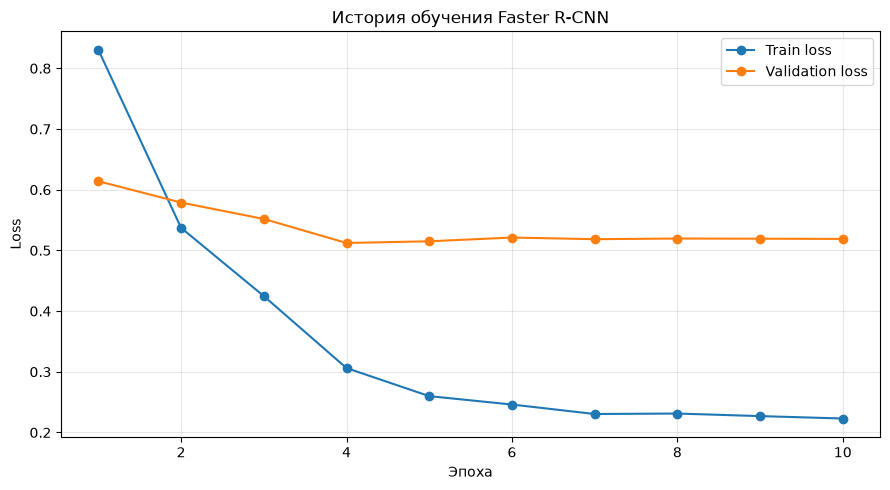

In [12]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)
plt.figure(figsize=(9, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train loss")
plt.plot(epochs, history["valid_loss"], marker="o", label="Validation loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("История обучения Faster R-CNN")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Оценка качества: mAP при разных IoU

Для каждого класса предсказания сортируются по confidence. Предсказание считается истинно положительным, если его IoU с ещё не сопоставленным объектом того же класса не меньше заданного порога. AP рассчитывается 101-точечной интерполяцией precision–recall, а mAP — усреднением AP по семи классам.

### 4.1. Вспомогательные функции

In [13]:
def load_model(checkpoint_path):
    loaded_model = fasterrcnn_resnet50_fpn_v2(weights=None, weights_backbone=None)
    set_predictor(loaded_model)
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    loaded_model.load_state_dict(checkpoint["model_state_dict"])
    return (loaded_model.to(DEVICE).eval(), checkpoint)
fine_tuned_model, best_checkpoint = load_model(BEST_MODEL_PATH)

<a id="metrics"></a>

### 4.2. Оценка качества

Обработано батчей: 10/32
Обработано батчей: 20/32
Обработано батчей: 30/32
Обработано батчей: 32/32


| Метрика | Значение |
| --- | --- |
| mAP@0.50 | 0.7286 |
| mAP@0.75 | 0.4670 |
| mAP@0.50:0.95 | 0.4389 |

| IoU | mAP |
| --- | --- |
| 0.50 | 0.7286 |
| 0.55 | 0.7187 |
| 0.60 | 0.6905 |
| 0.65 | 0.6394 |
| 0.70 | 0.5591 |
| 0.75 | 0.4670 |
| 0.80 | 0.3299 |
| 0.85 | 0.1691 |
| 0.90 | 0.0827 |
| 0.95 | 0.0037 |

| Класс | AP@0.50 |
| --- | --- |
| fish | 0.6822 |
| jellyfish | 0.7420 |
| penguin | 0.7634 |
| puffin | 0.5470 |
| shark | 0.8005 |
| starfish | 0.7845 |
| stingray | 0.7805 |

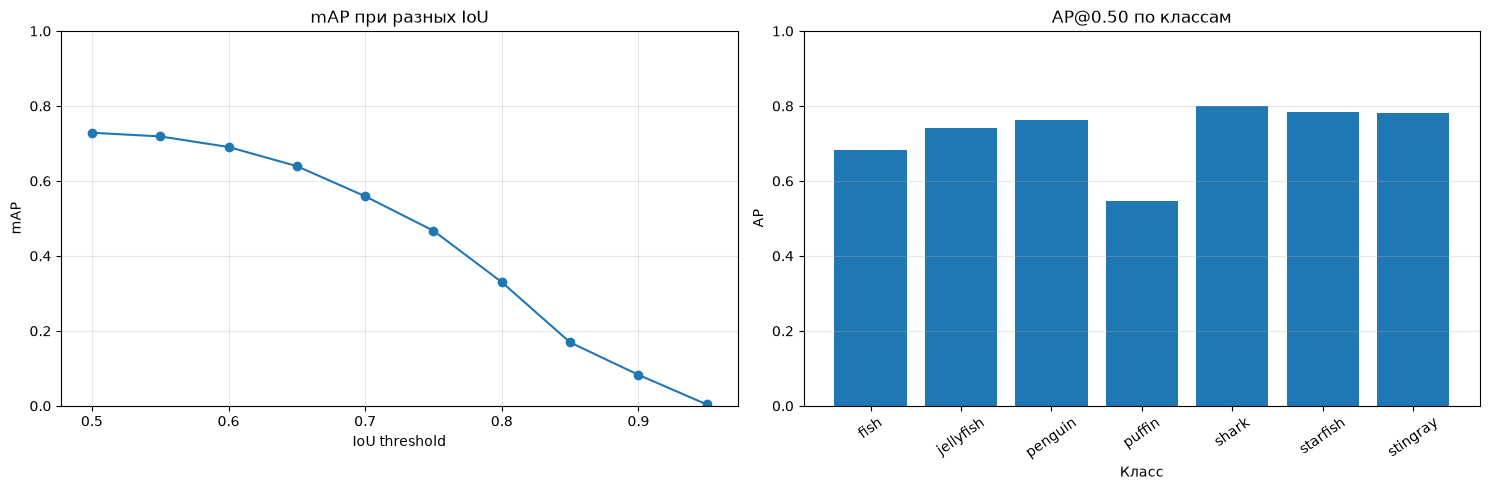

In [14]:
test_predictions, test_targets = collect_predictions(fine_tuned_model, test_loader)
iou_thresholds = [round(value / 100, 2) for value in range(50, 100, 5)]
class_ids = sorted(train_dataset.categories)
map_by_iou, ap_by_iou_and_class = evaluate_map(
    test_predictions, test_targets, class_ids, iou_thresholds
)

map_50 = map_by_iou[0.50]
map_75 = map_by_iou[0.75]
map_50_95 = sum(map_by_iou.values()) / len(map_by_iou)

from IPython.display import Markdown, display

def show_table(headers, rows):
    lines = ['| ' + ' | '.join(headers) + ' |',
             '| ' + ' | '.join(['---'] * len(headers)) + ' |']
    lines.extend('| ' + ' | '.join(map(str, row)) + ' |' for row in rows)
    display(Markdown('\n'.join(lines)))

show_table(['Метрика', 'Значение'], [
    ['mAP@0.50', f'{map_50:.4f}'],
    ['mAP@0.75', f'{map_75:.4f}'],
    ['mAP@0.50:0.95', f'{map_50_95:.4f}'],
])
show_table(['IoU', 'mAP'], [[f'{t:.2f}', f'{map_by_iou[t]:.4f}'] for t in iou_thresholds])
show_table(['Класс', 'AP@0.50'], [
    [train_dataset.categories[k], f'{ap_by_iou_and_class[0.50][k]:.4f}'] for k in class_ids
])

evaluation_results = {
    "mAP@0.50": map_50,
    "mAP@0.75": map_75,
    "mAP@0.50:0.95": map_50_95,
    "mAP_by_IoU": {str(key): value for key, value in map_by_iou.items()},
    "AP@0.50_by_class": {
        train_dataset.categories[class_id]: ap_by_iou_and_class[0.50][class_id]
        for class_id in class_ids
    },
}
with (ARTIFACTS_DIR / "evaluation_metrics.json").open("w", encoding="utf-8") as file:
    json.dump(evaluation_results, file, ensure_ascii=False, indent=2)

figure, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(iou_thresholds, [map_by_iou[value] for value in iou_thresholds], marker="o")
axes[0].set(title="mAP при разных IoU", xlabel="IoU threshold", ylabel="mAP")
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)

class_labels = [train_dataset.categories[class_id] for class_id in class_ids]
class_ap50 = [ap_by_iou_and_class[0.50][class_id] for class_id in class_ids]
axes[1].bar(class_labels, class_ap50)
axes[1].set(title="AP@0.50 по классам", xlabel="Класс", ylabel="AP")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=35)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "map_results.png", dpi=150, bbox_inches="tight")
plt.show()

<a id="predictions"></a>

## 5. Визуализация предсказаний на тестовых изображениях

Сравним исходную модель, обученную на COCO, с лучшим checkpoint после fine-tuning. Наборы классов COCO и Aquarium различаются, поэтому подписи исходной модели отображаются в исходном пространстве COCO; количественная оценка mAP выполняется только для дообученной модели в пространстве семи классов Aquarium.

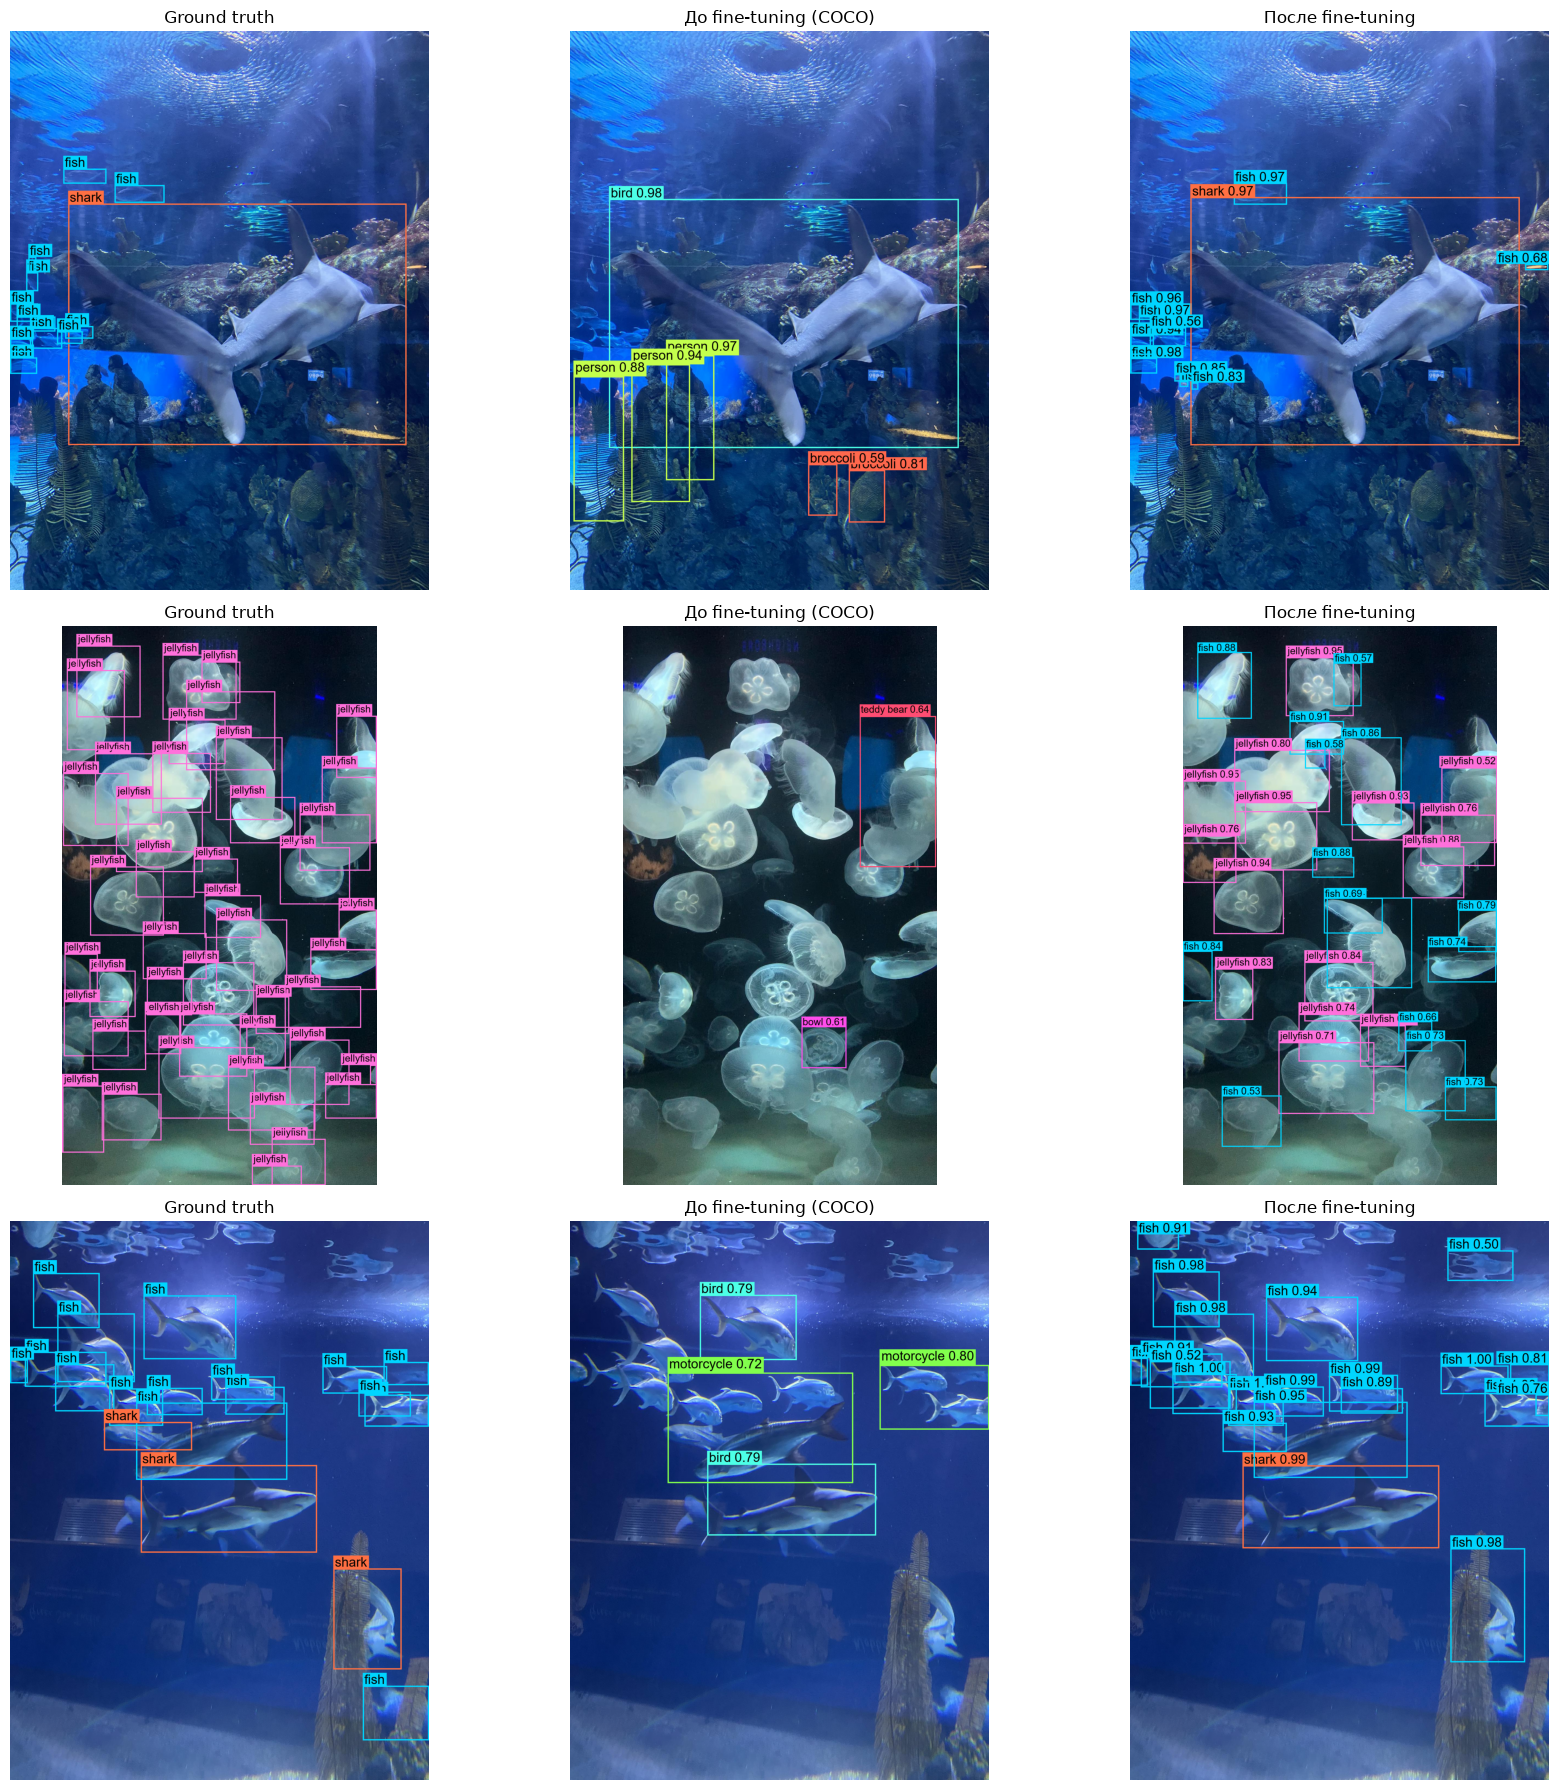

Загружен лучший checkpoint: эпоха 4, validation loss=0.5122


In [15]:
# Лучшая модель после fine-tuning.
with torch.inference_mode():
    tuned_predictions = fine_tuned_model([image.to(DEVICE) for image in sample_images])

figure, axes = plt.subplots(len(sample_images), 3, figsize=(18, 6 * len(sample_images)))
for row, (image, target, baseline, tuned) in enumerate(
    zip(sample_images, sample_targets, baseline_predictions, tuned_predictions)
):
    ground_truth = draw_detections(
        image, target["boxes"], target["labels"], aquarium_names, color="lime"
    )
    before = draw_detections(
        image, baseline["boxes"], baseline["labels"],
        {index: name for index, name in enumerate(class_names)},
        baseline["scores"], SCORE_THRESHOLD, "orange",
    )
    after = draw_detections(
        image, tuned["boxes"], tuned["labels"], aquarium_names,
        tuned["scores"], SCORE_THRESHOLD, "red",
    )
    for axis, rendered, title in zip(
        axes[row], [ground_truth, before, after],
        ["Ground truth", "До fine-tuning (COCO)", "После fine-tuning"],
    ):
        axis.imshow(rendered.permute(1, 2, 0))
        axis.set_title(title)
        axis.axis("off")

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "predictions_before_after.png", dpi=150, bbox_inches="tight")
plt.show()
print(
    f"Загружен лучший checkpoint: эпоха {best_checkpoint['epoch']}, "
    f"validation loss={best_checkpoint['best_valid_loss']:.4f}"
)

В работе Faster R-CNN ResNet-50 FPN v2 дообучена на семи классах Aquarium. Выбор checkpoint выполнен по validation loss; динамика обучения представлена на [графике функции потерь](#loss-history).

Качество на тестовой выборке отражено в [таблицах результатов и графиках mAP/AP](#metrics). [Сравнение предсказаний до и после дообучения с эталонной разметкой](#predictions) позволяет оценить изменения в распознавании объектов. Исходная COCO-модель и дообученная модель используют разные наборы классов, поэтому количественные метрики приведены для Aquarium.

### Контрольные вопросы

**1. Чем one-stage детекторы отличаются от two-stage?**

Главное различие — способ поиска объектов. One-stage детекторы, например YOLO и SSD, предсказывают классы и рамки по картам признаков без отдельного этапа отбора областей-кандидатов. В two-stage моделях сначала выделяются перспективные области, а затем каждая из них анализируется подробнее. В используемой Faster R-CNN за предложения отвечает RPN, после чего признаки областей извлекаются через RoIAlign и поступают в голову классификации и уточнения рамок.

One-stage подход часто выбирают для задач с ограничением по задержке. Two-stage подход позволяет отдельно обрабатывать найденные области, но добавляет вычисления. При этом точность определяется не только числом этапов: на неё влияют архитектура, разрешение изображений, данные и режим обучения.

**2. Какие ошибки чаще всего допускает модель при детекции?**

**Пропуск объекта**, **Ложное срабатывание**, **Неверный класс**, **Неточная рамка** и **Повторная детекция**.

Это возможные типы ошибок, а их частоту для конкретной модели следует устанавливать по разметке и предсказаниям. Порог уверенности меняет соотношение пропусков и ложных срабатываний: повышение порога обычно убирает часть сомнительных рамок, но может скрыть реальные объекты.
